# Configurations

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import sklearn.decomposition
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
import seaborn as sns; sns.set()
import math
from typing import List
from types import SimpleNamespace
from sklearn.model_selection import train_test_split

# Temporary
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import os
os.chdir("..")

# Data Preprocessing

In [ ]:
# The column names in the NSL KDD dataset
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",               
    "difficulty"           
]

train = pd.read_csv("data/KDDTrain+.txt", names=col_names)
test  = pd.read_csv("data/KDDTest+.txt",  names=col_names)

# Selected features
features = [
    # categorical
    "protocol_type", "service", "flag",

    # numeric
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

categorical = ["protocol_type", "service", "flag"]

numeric = [
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

preprocess = ColumnTransformer([ ("cat", OneHotEncoder(handle_unknown="ignore"), categorical), ("num", "passthrough", numeric) ])

# Training and testing set
X_train = train[features]
X_test  = test[features]

# Ensure string values are numerical
X_train = preprocess.fit_transform(X_train).toarray()
X_test  = preprocess.transform(X_test).toarray()

# Label normal traffic as 0 and attack traffic 1
# y_train = (train["label"] != "normal").astype(int).values
# y_test  = (test["label"] != "normal").astype(int).values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit on ALL labels so no unseen labels appear later
all_labels = pd.concat([train["label"], test["label"]], axis=0)
le.fit(all_labels)

# Now safely transform
y_train_full = le.transform(train["label"])
y_test       = le.transform(test["label"])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)


# Shape of data
num_features = X_train.shape[1] # 94 features

# X_train is already preprocessed earlier
N = len(X_train)
val_size = int(0.2 * N)

# Apply the same split to encoded labels
y_val   = y_train_full[:val_size]
y_train = y_train_full[val_size:]

X_val   = X_train[:val_size]
X_train = X_train[val_size:]

Number of classes: 40


In [6]:
print(X_test.shape)

(22544, 94)


In [5]:
X_full = np.concatenate([X_train, X_val, X_test], axis=0)
y_full = np.concatenate([y_train, y_val, y_test], axis=0)


X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Softmax Regression

In [6]:
def softmax(z):
    """Softmax function."""
    z = z - np.max(z, axis=1, keepdims=True)   # Safe from overflowing by subtracting max z value
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)


## Stochastic Gradient Descent (SGD)

In [7]:
def get_batch(xs, ys, B):
    """Return a random mini‑batch of size B from (xs, ys)."""
    assert len(xs) == len(ys), "xs and ys must contain the same number of samples."

    # Initialize batch arrays
    x_batch = np.zeros((B, xs.shape[1]))
    y_batch = np.zeros((B, 1))

    # Randomly sample B indices from the dataset
    idxs = np.random.randint(0, len(ys), size=B)

    # Fill the batch
    x_batch,y_batch = xs[idxs], ys[idxs]
    return x_batch, y_batch

In [8]:
def softmax_regression_gradient(xs_batch, ys_batch, W, alfa):
    """ Compute the gradients of the multi-class cross entropy loss w.r.t weights and bias for softmax regression
    
    Args:
        xs_batch: (B, num_features)
        ys_batch: (B,) integer labels
        W: (num_features+1, num_classes)
        
    Returns:
        ndarray: gradient_w (includes bias as w[0])
    """
    B = xs_batch.shape[0]       # number of samples in batch
    num_classes = W.shape[1]    # number of classes

    # Prepend a column of ones to xs_batch for the bias term
    Xb = np.zeros((B, num_features + 1))
    Xb[:, 0] = 1.0
    Xb[:, 1:] = xs_batch

    # Compute logits Xb*W
    z = Xb @ W                               # (B, num_classes)
    probabilities = softmax(z)               # (B, num_classes)

    # One-hot encode labels to match shape (B, num_classes)
    Y = np.zeros_like(probabilities)
    Y[np.arange(B), ys_batch] = 1

    # Compute gradient X^T * (p - y)
    grad_W = Xb.T @ (probabilities - Y)                   # (num_features+1, num_classes)

    # L2 regularization (skip bias)
    grad_W[1:] += alfa * W[1:]

    return grad_W

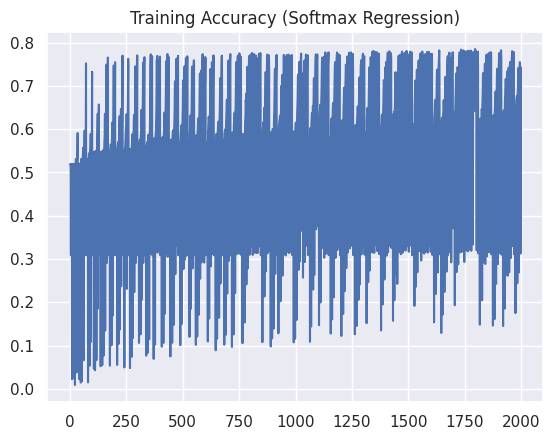

In [9]:
def stochastic_gradient_descent(xs, ys, T=10**4, lr=10**(-3), B=16, alfa=10**(-3), compAcc=False):
    """Compute SDG to optimize the weights and bias for the model

    Args:
        xs (ndarray): input data with size (N, num_features)
        ys (ndarray): output data, the labels with size (N,)
        T (int, optional): iterations. Defaults to 10**4.
        lr (float, optional): learning rate. Defaults to 10**(-3).
        B (int, optional): batch size. Defaults to 16.

    Returns:
        (ndarray), (ndarray)  : the weights with size (num_features,), bias and model accuracy with size (T,)
    """
    num_classes = 40
    accuracy = np.zeros(T)
    W = np.zeros((num_features + 1, num_classes))   # weights + bias

    for t in range(T):
        # Random sampling over dataset
        xs_batch, ys_batch = get_batch(xs, ys, B)   # (B, num_features) and (B, 1)

        # Compute the gradient for W
        grad_W = softmax_regression_gradient(xs_batch, ys_batch, W, alfa)   # (num_features+1,num_classes)

        # Update parameters via theta = prev theta - learning rate * gradient
        W -= lr * grad_W     # (num_features+1,num_classes)
        
        # Prediction and accuracy
        if compAcc:
            logits = xs @ W[1:] + W[0]                  # Compute logits X*W
            probs = softmax(logits)                     # Compute the probabilities via softmax function
            preds = np.argmax(probs, axis=1)            # Compute prediction of label with highest probability
            accuracy[t] = np.mean(preds == ys)          # Sum correct prediction accross whole dataset and take the mean

    return W, accuracy
W, acc = stochastic_gradient_descent(X_train, y_train, T=2000, B=256, alfa=1e-3, compAcc=True)
plt.plot(acc)
plt.title("Training Accuracy (Softmax Regression)")
plt.show()

# Generalization

## Grid search

best learning rate =  0.0001 with acc_val =  0.8205192947018474  and alfa =  0.0001


Text(0.0011, 0.6, 'maximum Acc')

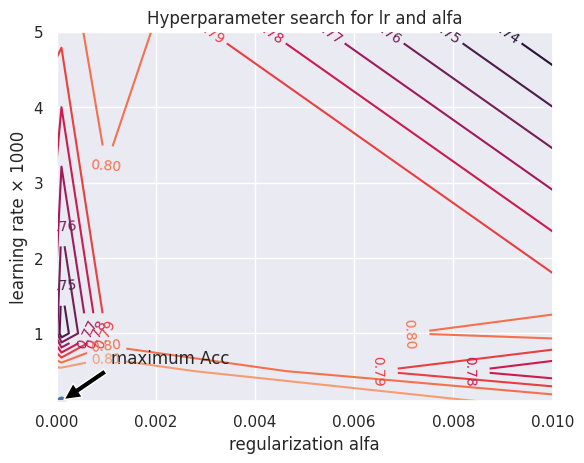

In [10]:
# Selected learning rate values
lrs  = [1e-4, 5e-4, 1e-3, 5e-3]

# Selected regularization strengths
alfas = [0.0, 1e-4, 1e-3, 1e-2]

Acc_by_lr_by_alfa = np.zeros((len(lrs), len(alfas)))

best_acc  = -1.0
best_lr   = None
best_alfa = None

# Grid search over learning rate and regularization
for lr_idx, lr in enumerate(lrs):
    for a_idx, alfa in enumerate(alfas):

        # Train logistic regression with these hyperparameters
        W, _ = stochastic_gradient_descent(X_train, y_train, T=10**4,lr=lr, B=256, alfa=alfa)

        # Validation predictions
        z = X_val @ W[1:] + W[0]          # Logits (B, num_classes)
        probs = softmax(z)                # Convert to probabilities
        preds = np.argmax(probs, axis=1)  # Choose class with highest probability

        # Validation accuracy
        acc = np.mean(y_val==preds)

        Acc_by_lr_by_alfa[lr_idx, a_idx] = acc

        # Track best hyperparameters
        if acc > best_acc:
            best_acc, best_lr, best_alfa = acc, lr, alfa

print('best learning rate = ', best_lr, 'with acc_val = ', best_acc,' and alfa = ', best_alfa)
fig, ax = plt.subplots()

lrs_scaled = np.array(lrs) * 1000
best_lr_scaled = best_lr * 1000

CS = ax.contour(alfas, lrs_scaled, Acc_by_lr_by_alfa, 10)
ax.clabel(CS, inline=True, fontsize=10)

ax.set_title('Hyperparameter search for lr and alfa')
ax.set_xlabel('regularization alfa')
ax.set_ylabel('learning rate × 1000')

ax.plot(best_alfa, best_lr_scaled, 'o')
ax.annotate('maximum Acc',
            xy=(best_alfa, best_lr_scaled),
            xytext=(best_alfa + 0.001, best_lr_scaled + 0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))

## Evaluation

In [19]:
def accuracy_score(y_true, y_pred):
    """Fraction of correct predictions."""
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred):
    """
    Multiclass confusion matrix.
    cm[i, j] = number of samples with true class i predicted as class j.
    """
    K = max(y_true.max(), y_pred.max()) + 1
    cm = np.zeros((K, K), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def precision_per_class(cm):
    """Precision for each class: TP / (TP + FP)."""
    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    return TP / np.clip(TP + FP, 1e-12, None)


def recall_per_class(cm):
    """Recall for each class: TP / (TP + FN)."""
    TP = np.diag(cm)
    FN = cm.sum(axis=1) - TP
    return TP / np.clip(TP + FN, 1e-12, None)

def f1_macro(y_true, y_pred):
    """Macro-averaged F1 score."""
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_per_class(cm)
    recall = recall_per_class(cm)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return np.mean(f1)

def f1_micro(y_true, y_pred):
    """Micro-averaged F1 score."""
    cm = confusion_matrix(y_true, y_pred)
    TP = np.diag(cm).sum()
    FP = cm.sum() - cm.sum(axis=1).sum()  # total predicted positives - TP
    FN = cm.sum() - cm.sum(axis=0).sum()  # total actual positives - TP

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return 2 * precision * recall / (precision + recall)

In [20]:
# Best model (W is now a matrix, not a vector)
W, _ = stochastic_gradient_descent(X_train, y_train, T=10**4, lr=best_lr, B=256, alfa=best_alfa)

# Compute training predictions (softmax)
Xb_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
logits = Xb_train @ W                     # (N, K) logits
probs = softmax(logits)                  # convert to probabilities
preds = np.argmax(probs, axis=1)         # decision rule: argmax
acc = accuracy_score(y_train, preds)
print('Training accuracy', acc)

# Add bias column to test data
Xb_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Compute test predictions (softmax)
logits = Xb_test @ W                     # (N, K) logits
probs = softmax(logits)                  # convert to probabilities
preds = np.argmax(probs, axis=1)         # decision rule: argmax

# Compute test accuracy and metrics
acc = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
prec = precision_per_class(cm)
rec = recall_per_class(cm)
f1_macro_score = f1_macro(y_test, preds)
f1_micro_score = f1_micro(y_test, preds)

# Print results
print('Test accuracy:', acc)
print('Precision per class:', prec)
print('Recall per class:', rec)
print('Macro F1:', f1_macro_score)
print('Micro F1:', f1_micro_score)

Training accuracy 0.8078905839032089
Test accuracy: 0.810059251279289
Precision per class: [0.03720577 0.         0.         0.         0.         0.
 0.         0.19402985 0.         0.         0.         0.
 0.         0.         0.89755186 0.         0.89434746 0.
 0.         0.         0.81015038 0.         0.         0.
 0.         0.50473934 0.         0.31649832 0.         0.
 0.         0.         0.26041667 0.         0.         0.1122449
 0.         0.         0.         0.        ]
Recall per class: [0.33108108 0.         0.         0.         0.         0.
 0.         0.17379679 0.         0.         0.         0.
 0.         0.         0.99509483 0.         0.89423139 0.
 0.         0.         0.697411   0.         0.         0.
 0.         0.24370709 0.         0.42598187 0.         0.
 0.         0.         0.13812155 0.         0.         0.11398964
 0.         0.         0.         0.        ]
Macro F1: 0.09558507922278062
Micro F1: 1.0


Note: This indicates that model only accuracetly guess correctly majority classes. We have class imbalance! A deeper model may be better for 40 classes.